In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [28]:
def get_transactions(wallet):
    wallet = wallet.lower()

    txs = df[
        (df["from"].str.lower() == wallet) |
        (df["to"].str.lower() == wallet)
    ]

    return txs.to_dict("records")

In [29]:
def trace_wallet(start_address, max_hops):
    visited = set()
    graph = []

    current_wallets = [start_address]

    for hop in range(max_hops):
        next_wallets = []

        for wallet in current_wallets:

            if wallet in visited:
                continue

            visited.add(wallet)

            transactions = get_transactions(wallet)

            for tx in transactions:

                sender = tx["from"]
                receiver = tx["to"]

                graph.append({
                    "from": sender,
                    "to": receiver,
                    "tx_hash": tx["tx_hash"],
                    "value": tx["value"],
                    "hop": hop + 1
                })

                if receiver not in visited:
                    next_wallets.append(receiver)

        current_wallets = next_wallets

    return graph

In [30]:
df = pd.read_csv("../../data/sepolia_transactions.csv")
    
print("Transactions:", len(df))
print("Columns:", df.columns.tolist())

Transactions: 2618
Columns: ['tx_hash', 'from', 'to', 'value', 'block_number']


In [31]:
trace_wallet("0x280db72ffacb24a712308adcacaefcf8218254fe",2)

[{'from': '0x280db72ffacb24a712308adcacaefcf8218254fe',
  'to': '0xf15434e76bd53c9c60bfbbbcf37793b7fbd07f3d',
  'tx_hash': '0xb1e45ad010521551c42cb7d274c3044a4436c1d3a102d3ed0f57d7ea91eace43',
  'value': '0x11c37937e08000',
  'hop': 1},
 {'from': '0x280db72ffacb24a712308adcacaefcf8218254fe',
  'to': '0x45e3a5c20d63d9c5951da48603b5d7fc8b5029b6',
  'tx_hash': '0xd0d9d184ccde5806df072d86ec7ad830568bc4f90eecb43e0d45843b1b4eb2f0',
  'value': '0x11c37937e08000',
  'hop': 1},
 {'from': '0x280db72ffacb24a712308adcacaefcf8218254fe',
  'to': '0x45e3a5c20d63d9c5951da48603b5d7fc8b5029b6',
  'tx_hash': '0x3a6d92620c3f937b166108b49f3415a7115e4fb9f7fcc9ae4fc9796ac7d362c4',
  'value': '0x11c37937e08000',
  'hop': 1},
 {'from': '0x280db72ffacb24a712308adcacaefcf8218254fe',
  'to': '0x16f5d6995e535f215a292d685a8a04e2427fe6a8',
  'tx_hash': '0xf65aafff137e9b3682867971a607753b1ec937ace7ced978d0b75dd6685e906f',
  'value': '0x11c37937e08000',
  'hop': 1},
 {'from': '0x280db72ffacb24a712308adcacaefcf8218254f

Trace nodes: 5
Trace edges: 5


/tmp/ipykernel_68707/2662298072.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


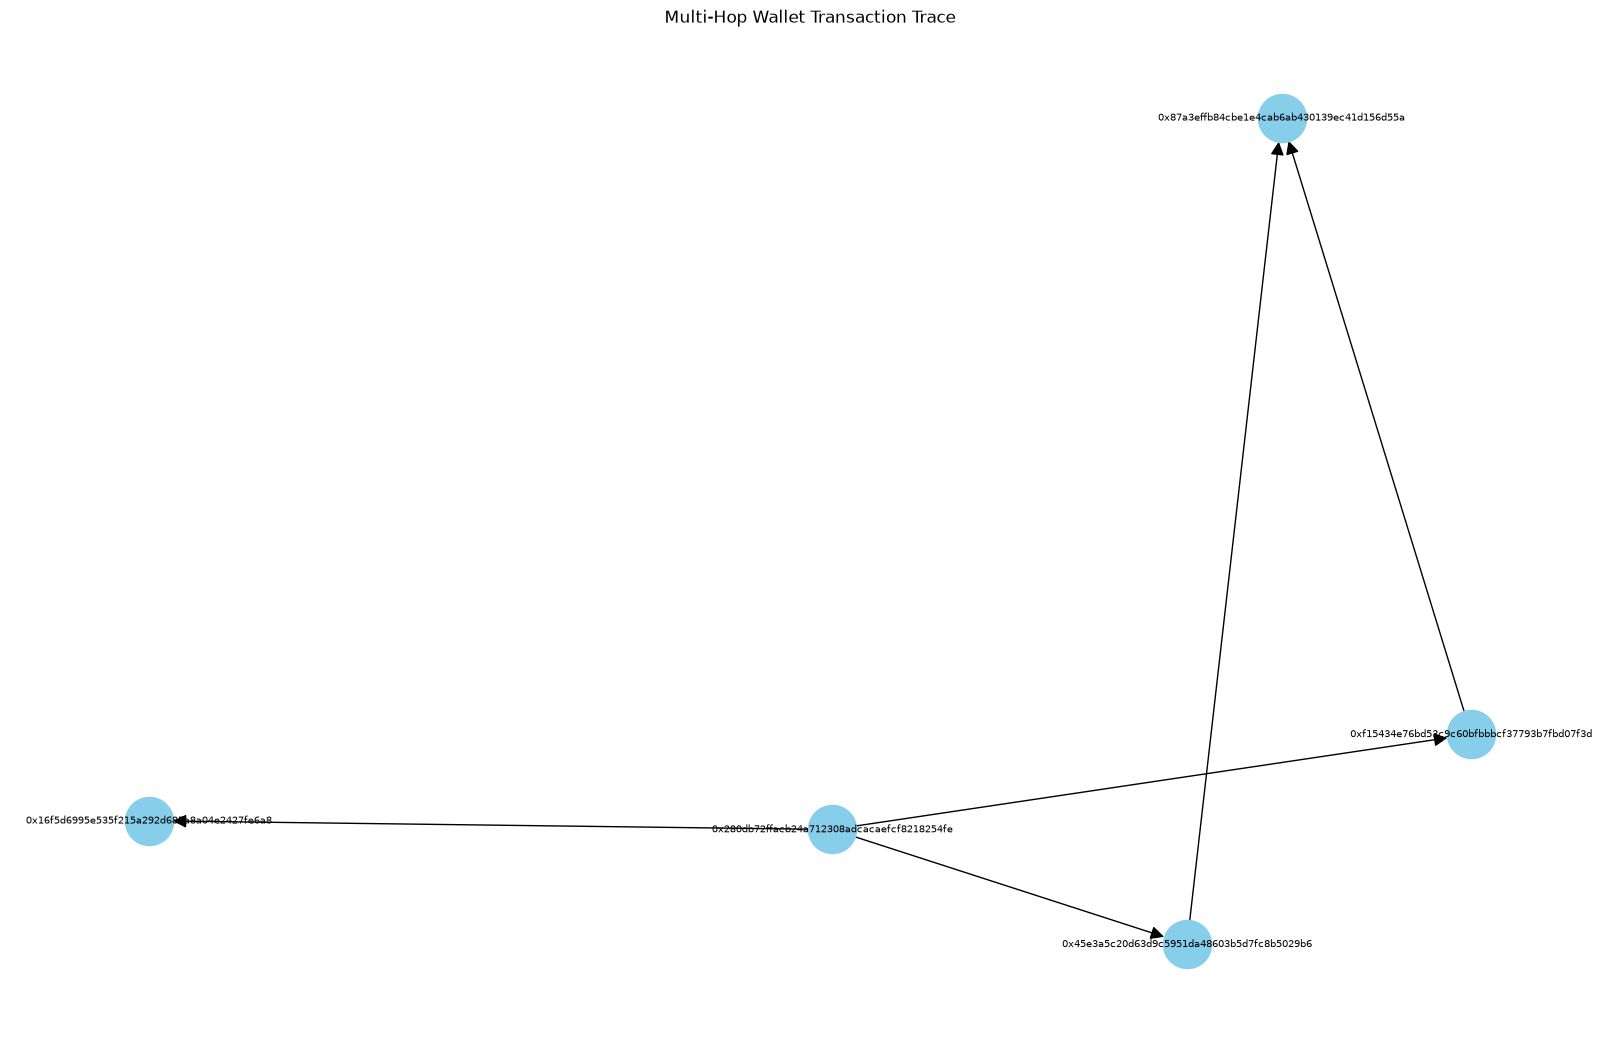

In [33]:
transaction=trace_wallet("0x280db72ffacb24a712308adcacaefcf8218254fe",2)
G_trace = nx.DiGraph()

for tx in transaction:

    G_trace.add_edge(
        tx["from"],
        tx["to"],
        tx_hash=tx["tx_hash"],
        value=tx["value"],
        hop=tx["hop"]
    )
print("Trace nodes:", G_trace.number_of_nodes())
print("Trace edges:", G_trace.number_of_edges())

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    G_trace,
    k=0.8,
    iterations=50,
    seed=42
)

nx.draw(
    G_trace,
    pos,
    with_labels=True,
    node_size=1200,
    node_color="skyblue",
    arrows=True,
    arrowsize=20,
    font_size=7
)

plt.title(
    "Multi-Hop Wallet Transaction Trace"
)

plt.tight_layout()
plt.show()